Here we try to get directions for safety and utility on gemma-3-1b-it

# imports

In [2]:
import torch
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

/home/khalidraisi/.conda/envs/532env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load model and datasets

In [3]:
model_name = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

#harmful prompts
advbench = load_dataset("walledai/AdvBench")
harmful_prompts = advbench['train']['prompt']

#harmless prompts
alpaca = load_dataset("tatsu-lab/alpaca")
harmless_prompts = [entry['instruction'] for entry in alpaca['train']]

#utility prompts
helpsteer = load_dataset("nvidia/HelpSteer")
utility_prompts = [entry['prompt'] for entry in helpsteer['train']]

N = 100
harmful_prompts = harmful_prompts[:N]
harmless_prompts = harmless_prompts[:N]
utility_prompts = utility_prompts[:N]

Generating validation split: 100%|██████████| 1789/1789 [00:00<00:00, 81243.95 examples/s]


# Get activations from all layers 

In [ ]:
def get_activations(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    return [h[:, -1, :].float().cpu().numpy()[0] for h in outputs.hidden_states]

# store all activations from respective dataset
harmful = np.array([get_activations(prompt) for prompt in tqdm(harmful_prompts, desc="harmful")])
harmless = np.array([get_activations(prompt) for prompt in tqdm(harmless_prompts, desc="harmless")])
utility = np.array([get_activations(prompt) for prompt in tqdm(utility_prompts, desc="utility")])

np.save("activations/harmful_activations.npy", harmful)
np.save("activations/harmless_activations.npy", harmless)
np.save("activations/utility_activations.npy", utility)

utility: 100%|██████████| 100/100 [34:12<00:00, 20.52s/it]


# Implement and apply DoM then use cosine similarity on extracted directions

In [4]:
# all have the same size/shape anyways
num_layers = harmful.shape[1]
cosine_similarities = []

#This is same as what was put previously in EDA.ipynb just modified for all layers
for layer in range(num_layers):
    # mean of activations
    harm_mean = harmful[:, layer, :].mean(axis=0)
    help_mean = utility[:, layer, :].mean(axis=0)
    alp_mean = harmless[:, layer, :].mean(axis=0)

    #DoM here extract safety/utility directions 
    refusal_direction = harm_mean - alp_mean
    utility_direction = help_mean - alp_mean

    #for neater results normalize and also recall with cosine similarity that closer to 0 means closer to being independent
    refusal_direction /= np.linalg.norm(refusal_direction)
    utility_direction /= np.linalg.norm(utility_direction)
    cosine_similarities.append(np.dot(refusal_direction, utility_direction))

# Plots and other stuff

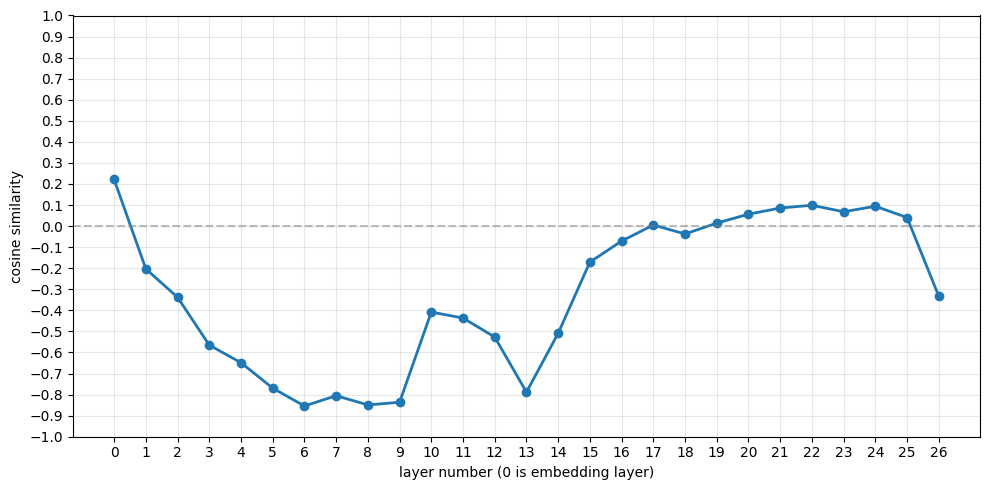

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(range(num_layers), cosine_similarities, marker='o', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("layer number (0 is embedding layer)")
plt.ylabel("cosine similarity")
plt.xticks(range(0, num_layers, 1))
plt.yticks(np.arange(-1, 1.1, 0.1))
plt.grid(True, alpha=0.3)
plt.tight_layout()

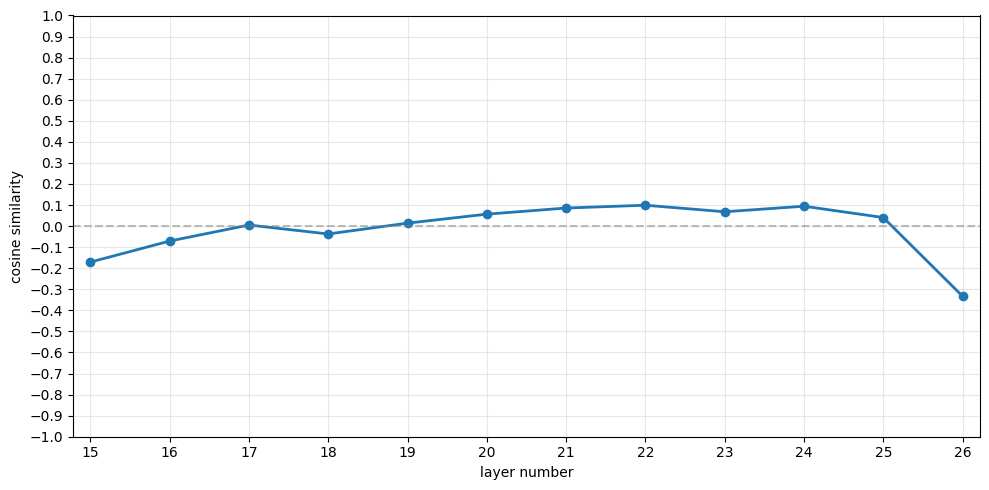

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(range(15, num_layers), cosine_similarities[15:], marker='o', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("layer number")
plt.ylabel("cosine similarity")
plt.xticks(range(15, num_layers, 1))
plt.yticks(np.arange(-1, 1.1, 0.1))
plt.grid(True, alpha=0.3)
plt.margins(x=0.02)
plt.tight_layout()
plt.show()

In [7]:
for i, cos_sim in enumerate(cosine_similarities):
    print(f"layer {i} cosine similarity: {cos_sim:.4f}")

layer 0 cosine similarity: 0.2213
layer 1 cosine similarity: -0.2033
layer 2 cosine similarity: -0.3381
layer 3 cosine similarity: -0.5650
layer 4 cosine similarity: -0.6486
layer 5 cosine similarity: -0.7694
layer 6 cosine similarity: -0.8542
layer 7 cosine similarity: -0.8051
layer 8 cosine similarity: -0.8491
layer 9 cosine similarity: -0.8363
layer 10 cosine similarity: -0.4081
layer 11 cosine similarity: -0.4365
layer 12 cosine similarity: -0.5268
layer 13 cosine similarity: -0.7883
layer 14 cosine similarity: -0.5090
layer 15 cosine similarity: -0.1708
layer 16 cosine similarity: -0.0710
layer 17 cosine similarity: 0.0052
layer 18 cosine similarity: -0.0373
layer 19 cosine similarity: 0.0142
layer 20 cosine similarity: 0.0567
layer 21 cosine similarity: 0.0858
layer 22 cosine similarity: 0.0991
layer 23 cosine similarity: 0.0682
layer 24 cosine similarity: 0.0944
layer 25 cosine similarity: 0.0409
layer 26 cosine similarity: -0.3328


In [8]:
import sys
from pathlib import Path
import numpy as np


PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "dom"))
sys.path.insert(0, str(PROJECT_ROOT / "locatelayers"))

import dom
import layers_similarity as ll

In [9]:
ACT_DIR = PROJECT_ROOT / "activations" / "gemma3acts" / "1b"

harmful_1b  = np.load(ACT_DIR / "harmful_1b_n500_activations.npy")
harmless_1b = np.load(ACT_DIR / "harmless_1b_n500_activations.npy")
utility_1b  = np.load(ACT_DIR / "utility_1b_n500_activations.npy")

print("harmful :", harmful_1b.shape)
print("harmless:", harmless_1b.shape)
print("utility :", utility_1b.shape)

harmful : (500, 27, 1152)
harmless: (500, 27, 1152)
utility : (500, 27, 1152)


In [10]:
ACT_DIR = PROJECT_ROOT / "activations" / "gemma3acts" / "4b"

harmful  = np.load(ACT_DIR / "harmful_4b_n500_activations.npy")
harmless = np.load(ACT_DIR / "harmless_4b_n500_activations.npy")
utility  = np.load(ACT_DIR / "utility_4b_n500_activations.npy")

print("harmful :", harmful.shape)
print("harmless:", harmless.shape)
print("utility :", utility.shape)

harmful : (500, 35, 2560)
harmless: (500, 35, 2560)
utility : (500, 35, 2560)


# 1b

Permutation Test: 100%|██████████| 5000/5000 [01:28<00:00, 56.63it/s]


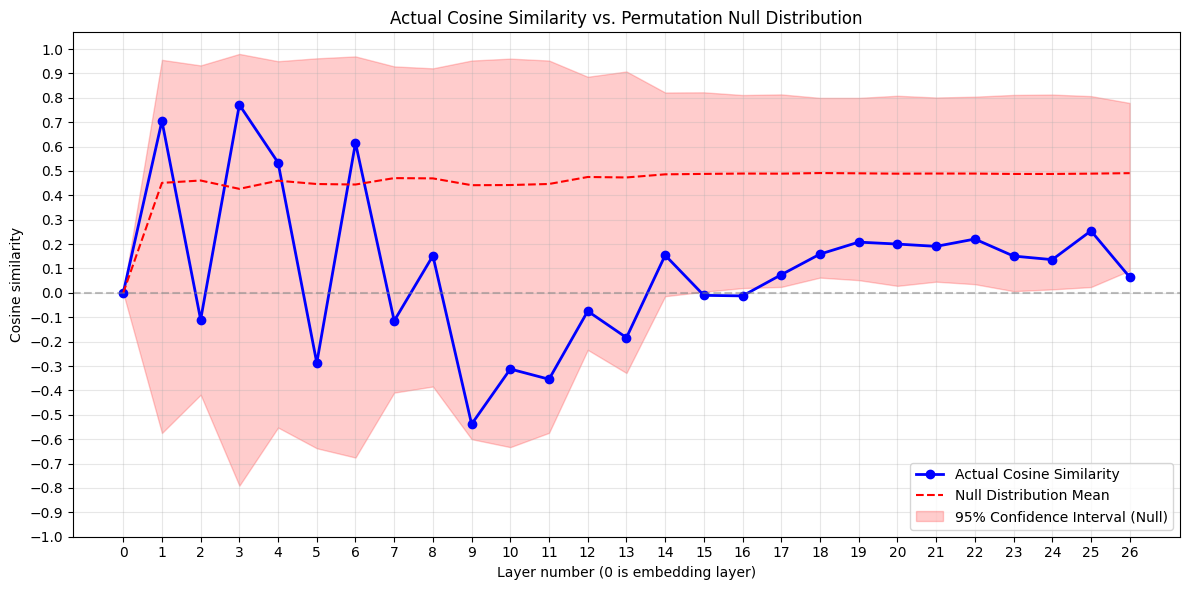

In [11]:
cos_sims = dom.dom_cosine_similarities(
    base=harmless_1b,
    group_a=harmful_1b,
    group_b=utility_1b,
)

mean_null, lower, upper = dom.dom_permutation_test(
    base=harmless_1b,
    group_a=harmful_1b,
    group_b=utility_1b,
    n_iterations=5000,
)

dom.dom_plot(cos_sims, mean_null, lower, upper)

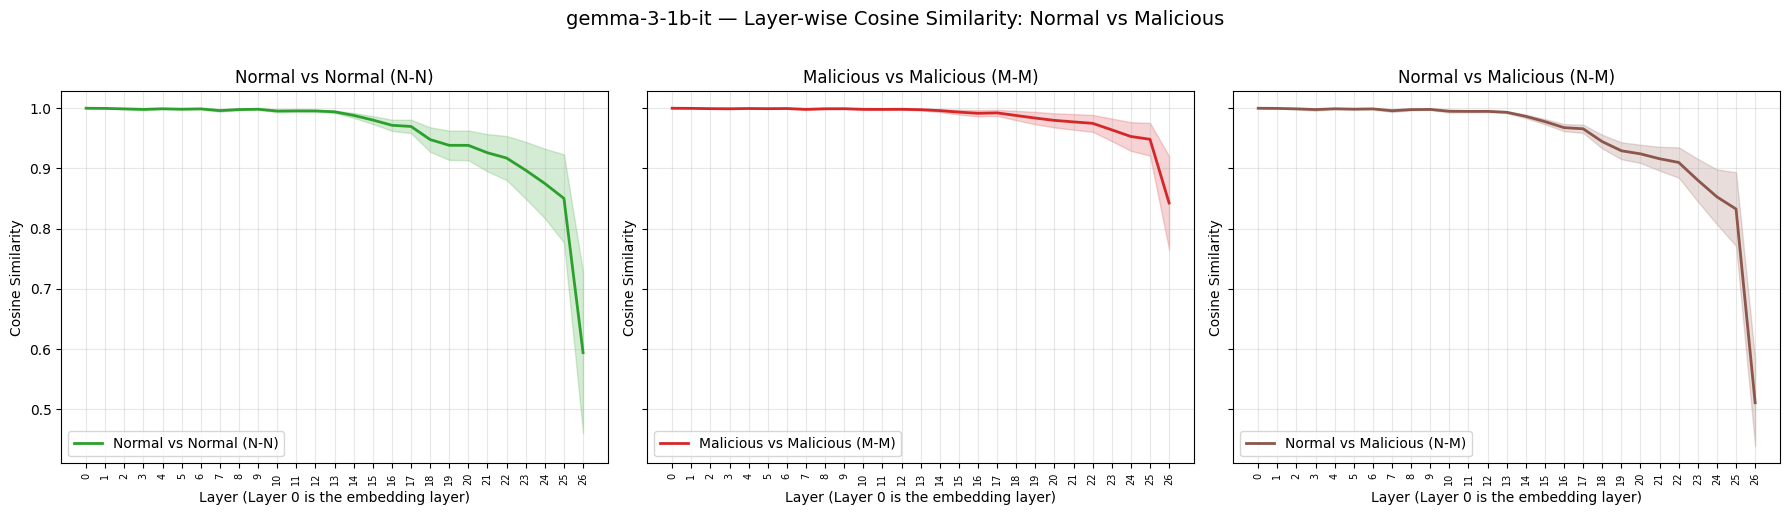

In [12]:
a_mean, a_std, c_mean, c_std, x_mean, x_std = ll.get_similarity_plot(
    anchor_acts=harmless_1b,
    contrast_acts=harmful_1b,
    anchor_label="Normal",
    contrast_label="Malicious",
    anchor_code="N",
    contrast_code="M",
    model_name="gemma-3-1b-it",
    combined=False,
)

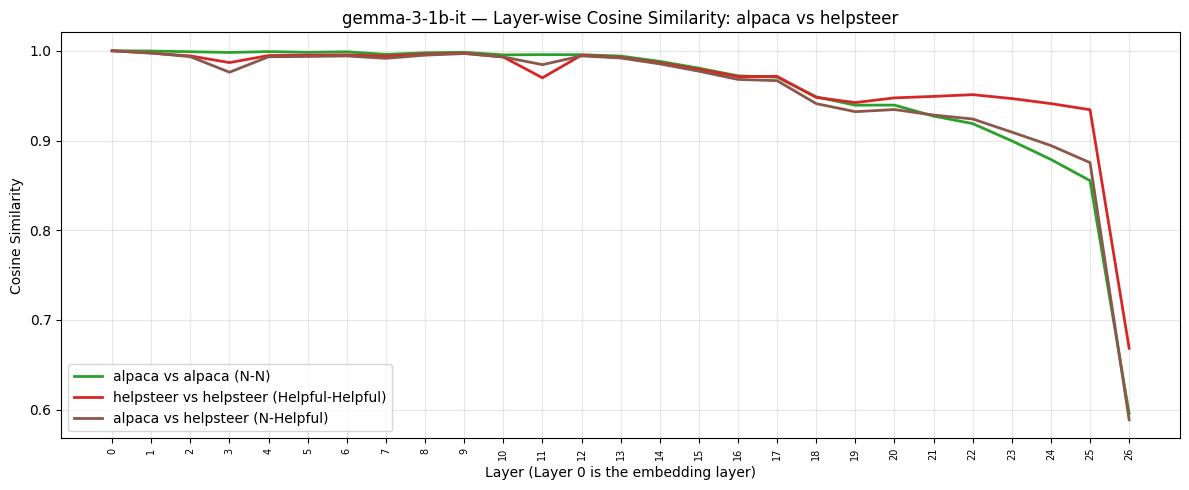

In [13]:
a_mean, a_std, c_mean, c_std, x_mean, x_std = ll.get_similarity_plot(
    anchor_acts=harmless_1b,
    contrast_acts=utility_1b,
    anchor_label="alpaca",
    contrast_label="helpsteer",
    anchor_code="N",
    contrast_code="Helpful",
    model_name="gemma-3-1b-it",
    combined=True,
)

# 4b

Permutation Test: 100%|██████████| 5000/5000 [03:09<00:00, 26.41it/s]


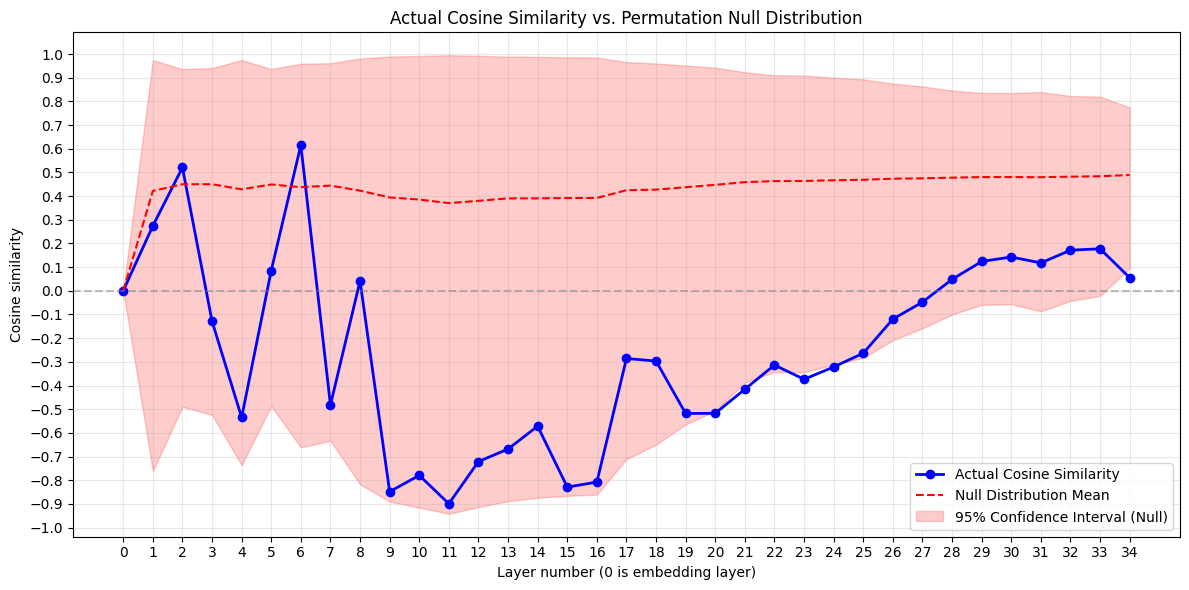

In [14]:
cos_sims = dom.dom_cosine_similarities(
    base=harmless,
    group_a=harmful,
    group_b=utility,
)

mean_null, lower, upper = dom.dom_permutation_test(
    base=harmless,
    group_a=harmful,
    group_b=utility,
    n_iterations=5000,
)

dom.dom_plot(cos_sims, mean_null, lower, upper)

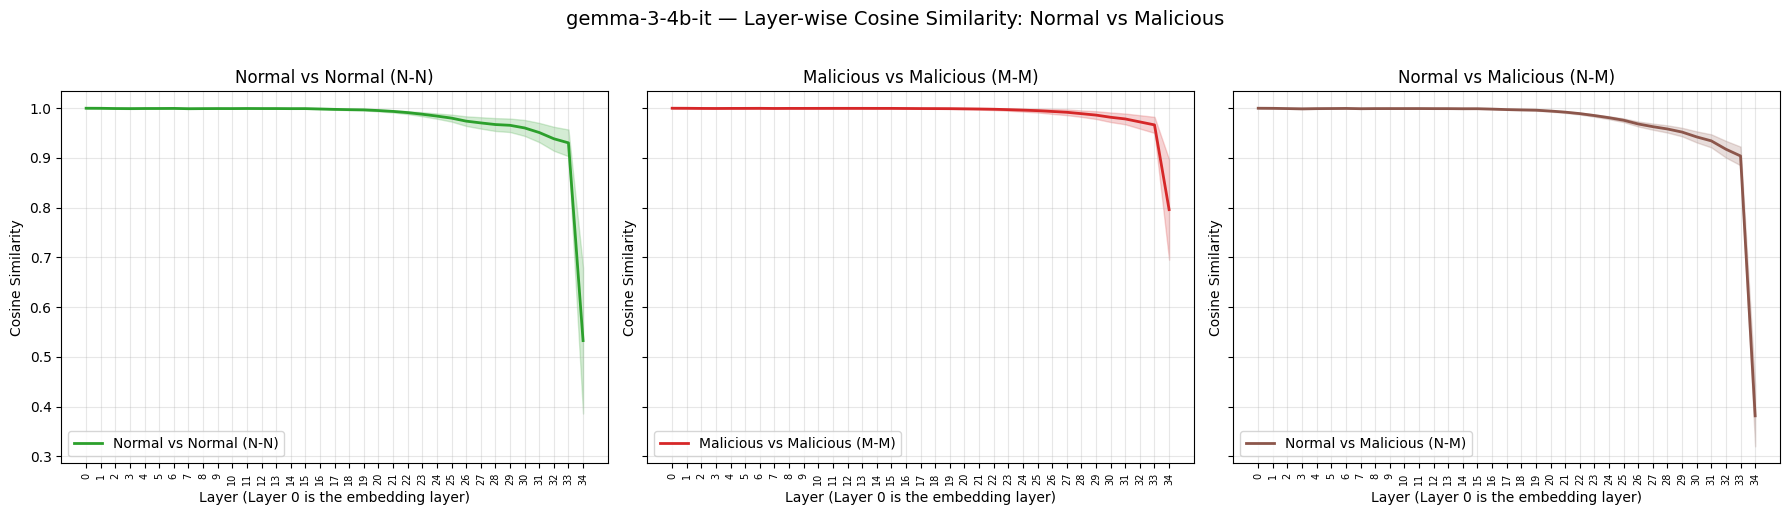

In [15]:
a_mean, a_std, c_mean, c_std, x_mean, x_std = ll.get_similarity_plot(
    anchor_acts=harmless,
    contrast_acts=harmful,
    anchor_label="Normal",
    contrast_label="Malicious",
    anchor_code="N",
    contrast_code="M",
    model_name="gemma-3-4b-it",
    combined=False,
)

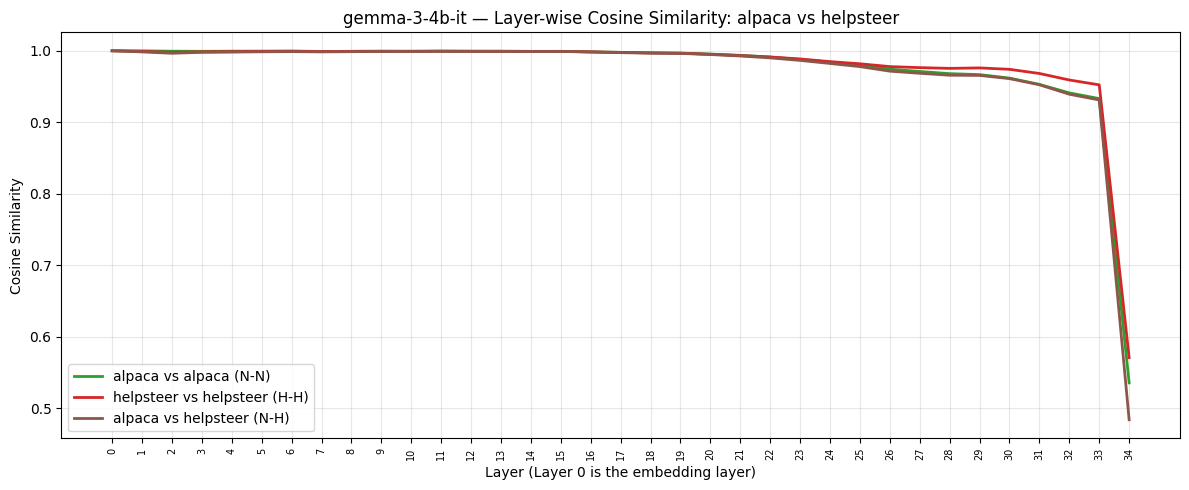

In [16]:
a_mean, a_std, c_mean, c_std, x_mean, x_std = ll.get_similarity_plot(
    anchor_acts=harmless,
    contrast_acts=utility,
    anchor_label="alpaca",
    contrast_label="helpsteer",
    anchor_code="N",
    contrast_code="H",
    model_name="gemma-3-4b-it",
    combined=True,
)